         id case_number                     date                block  iucr  \
0  14176675    JK229574  2026-04-20T00:00:00.000    047XX S ELLIS AVE  1120   
1  14174114    JK225921  2026-04-20T00:00:00.000  008XX N RICHMOND ST  1150   
2  14172558    JK224327  2026-04-20T00:00:00.000   005XX N ALBANY AVE  0820   
3  14172498    JK224417  2026-04-20T00:00:00.000   014XX N KEDZIE AVE  0910   
4  14172312    JK224159  2026-04-20T00:00:00.000   124XX S NORMAL AVE  1310   

          primary_type        description location_description  arrest  \
0   DECEPTIVE PRACTICE            FORGERY            APARTMENT   False   
1   DECEPTIVE PRACTICE  CREDIT CARD FRAUD               STREET   False   
2                THEFT     $500 AND UNDER               STREET   False   
3  MOTOR VEHICLE THEFT         AUTOMOBILE               STREET   False   
4      CRIMINAL DAMAGE        TO PROPERTY            RESIDENCE   False   

   domestic  ...  ward  community_area  fbi_code  x_coordinate y_coordinate  \
0

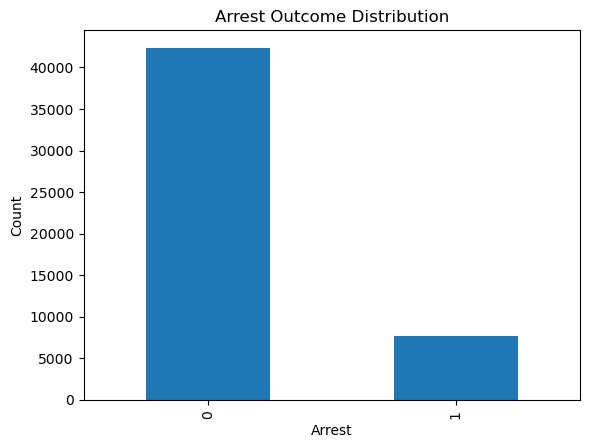

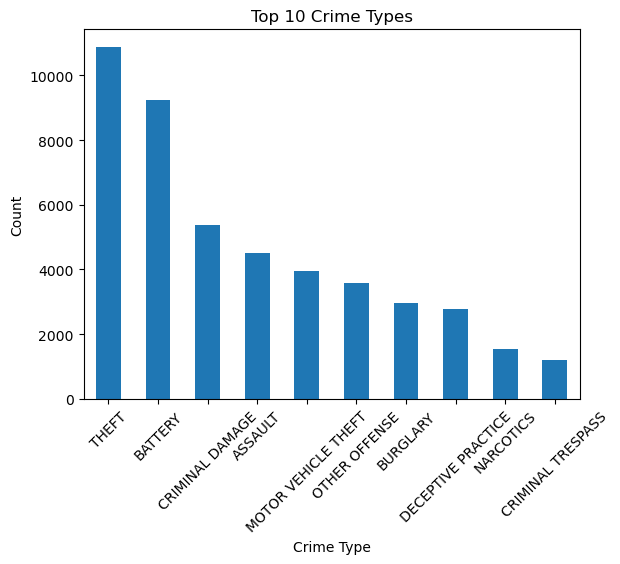

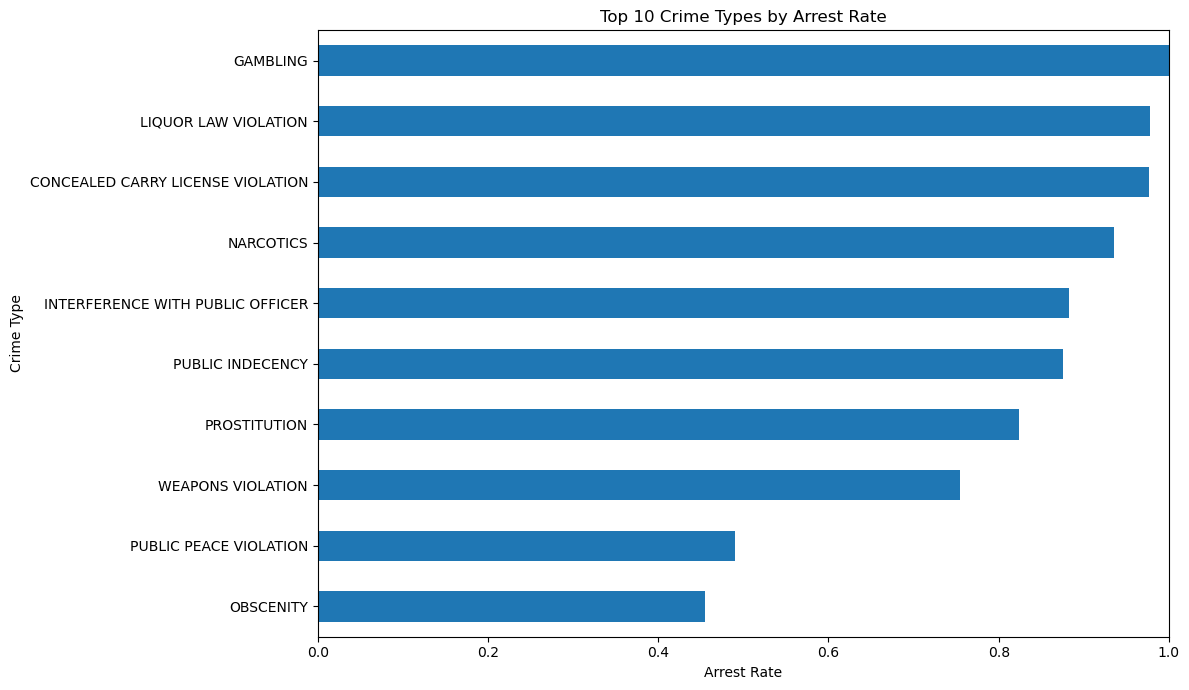

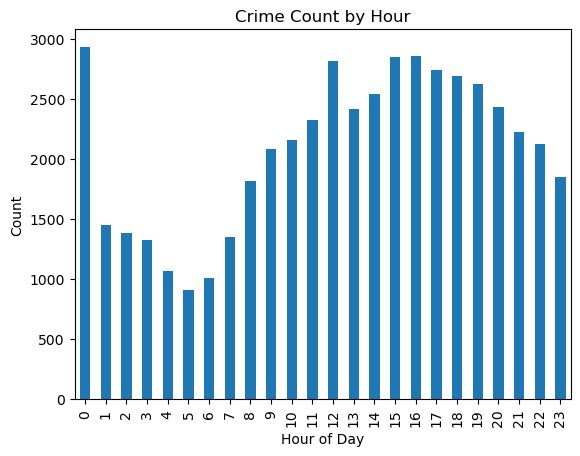

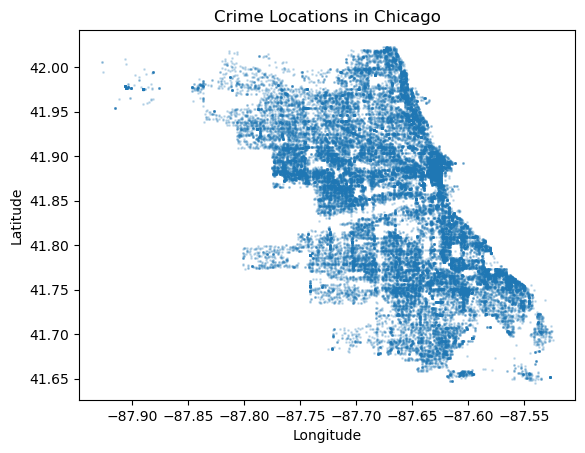

Categorical features: ['primary_type', 'description', 'location_description', 'domestic']
Numeric features: ['beat', 'district', 'ward', 'community_area', 'year', 'latitude', 'longitude']

Training: Logistic Regression

 Logistic Regression
Accuracy: 0.8969
Precision: 0.8734939759036144
Recall: 0.3798297314996726
F1 Score: 0.5294386125057051
ROC-AUC: 0.8825967550069094

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      8473
           1       0.87      0.38      0.53      1527

    accuracy                           0.90     10000
   macro avg       0.89      0.68      0.74     10000
weighted avg       0.89      0.90      0.88     10000



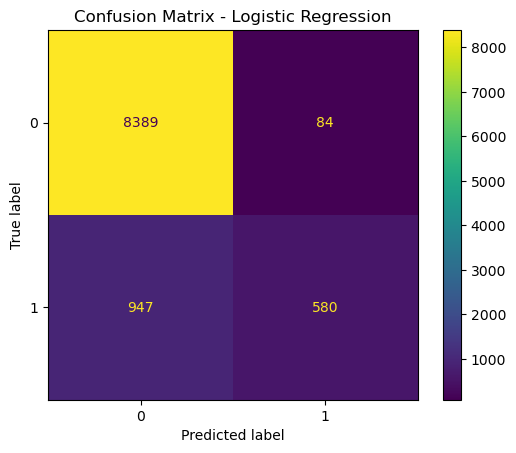

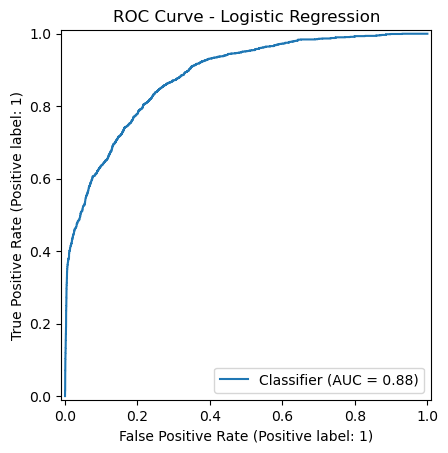


Training: Random Forest

 Random Forest
Accuracy: 0.8894
Precision: 0.68068669527897
Recall: 0.5193189259986902
F1 Score: 0.5891530460624071
ROC-AUC: 0.8602942773420034

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      8473
           1       0.68      0.52      0.59      1527

    accuracy                           0.89     10000
   macro avg       0.80      0.74      0.76     10000
weighted avg       0.88      0.89      0.88     10000



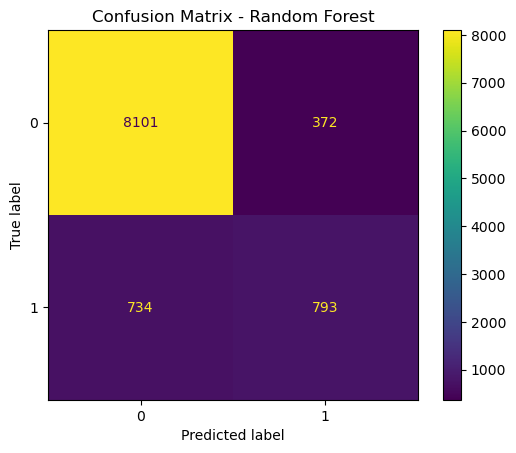

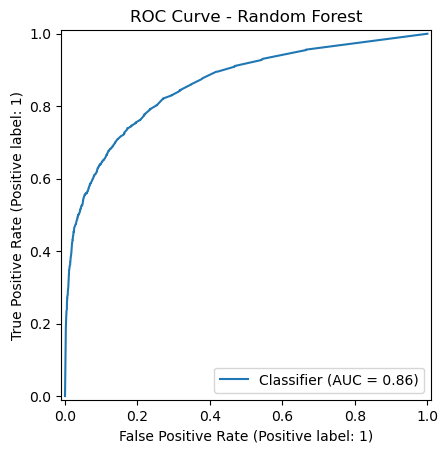


Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression    0.8969   0.873494  0.379830  0.529439  0.882597
1        Random Forest    0.8894   0.680687  0.519319  0.589153  0.860294


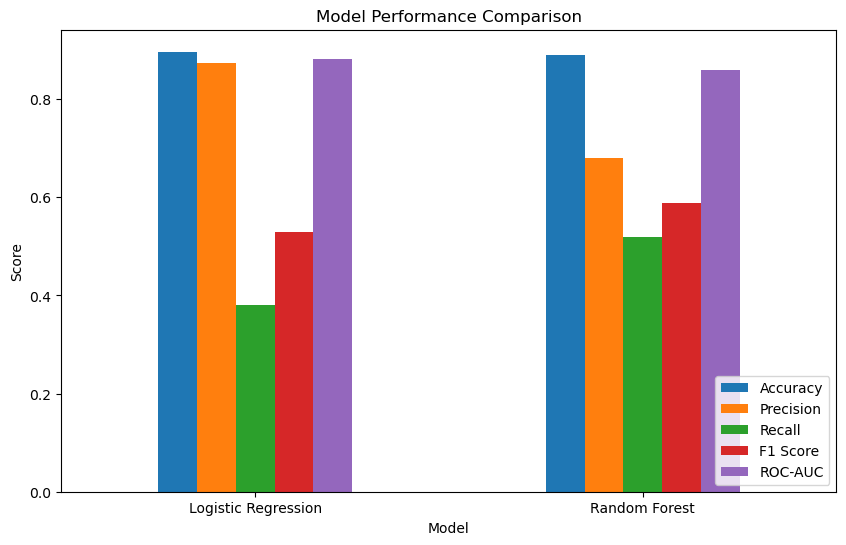


Top 20 Important Features:
                                       Feature  Importance
6                                    longitude    0.114448
5                                     latitude    0.113832
0                                         beat    0.076076
23                      primary_type_NARCOTICS    0.058360
3                               community_area    0.051222
2                                         ward    0.050799
1                                     district    0.033988
269  description_UNLAWFUL POSSESSION - HANDGUN    0.023398
34              primary_type_WEAPONS VIOLATION    0.018227
227                   description_RETAIL THEFT    0.016235
33                          primary_type_THEFT    0.016030
35                  description_$500 AND UNDER    0.014085
193                      description_OVER $500    0.013781
12                primary_type_CRIMINAL DAMAGE    0.013442
10                       primary_type_BURGLARY    0.012864
22            primary_type_M

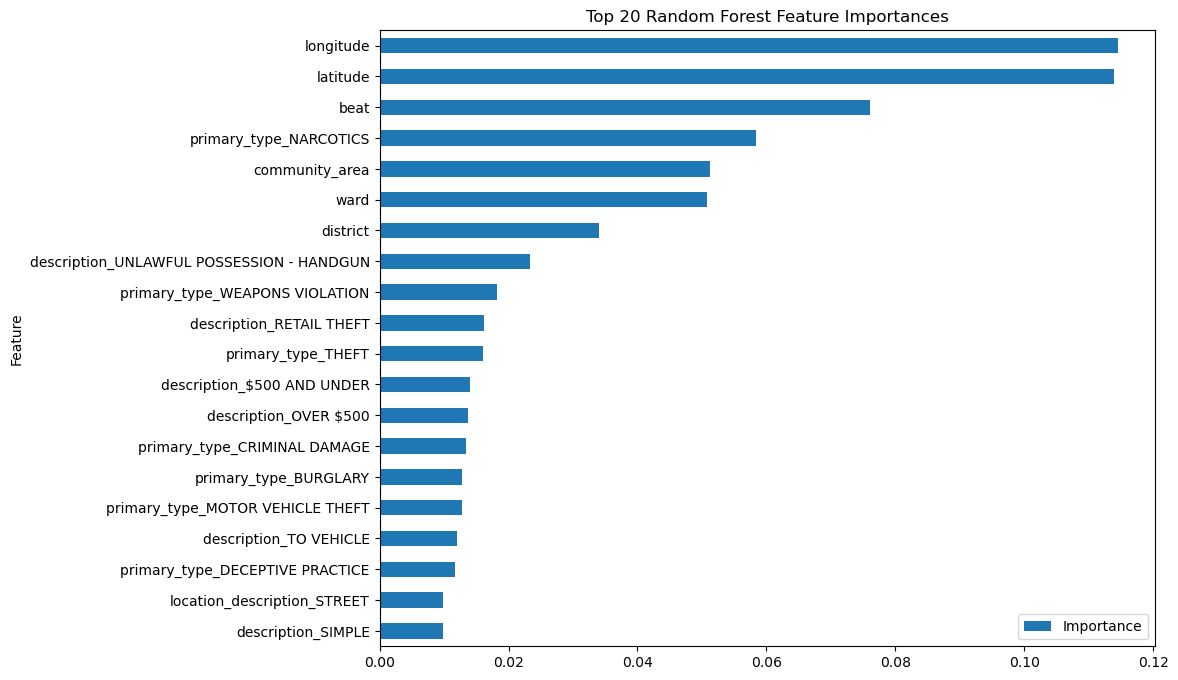

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Data loading


url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=50000"

df = pd.read_csv(url)

print(df.head())
print(df.shape)
print(df.info())


#  Cleaning

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["hour"] = df["date"].dt.hour
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

features = [
    "primary_type",
    "description",
    "location_description",
    "domestic",
    "beat",
    "district",
    "ward",
    "community_area",
    "year",
    "latitude",
    "longitude",
    "hour",
    "month",
    "day_of_week"
]

target = "arrest"

df_model = df[features + [target]].copy()

df_model = df_model.dropna(subset=[target])

df_model[target] = df_model[target].astype(int)

print(df_model.head())
print(df_model[target].value_counts())

#  Data Analysis


df_model[target].value_counts().plot(kind="bar")
plt.title("Arrest Outcome Distribution")
plt.xlabel("Arrest")
plt.ylabel("Count")
plt.show()

df_model["primary_type"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

arrest_rate_by_crime = (
    df_model.groupby("primary_type")[target]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))
arrest_rate_by_crime.sort_values().plot(kind="barh")

plt.title("Top 10 Crime Types by Arrest Rate")
plt.xlabel("Arrest Rate")
plt.ylabel("Crime Type")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

df_model["hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Crime Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.show()

plt.scatter(df_model["longitude"], df_model["latitude"], s=1, alpha=0.2)
plt.title("Crime Locations in Chicago")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Train-Test Split

X = df_model.drop(target, axis=1)
y = df_model[target]

categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing 

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


#  Models

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

# Train Models

results = []

for model_name, model in models.items():
    print("\nTraining:", model_name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("\n", model_name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("Confusion Matrix - " + model_name)
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title("ROC Curve - " + model_name)
    plt.show()

# Compare Results

results_df = pd.DataFrame(results)

print("\nModel Comparison:")
print(results_df)

results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

# Feature Importance for Random Forest

random_forest_model.fit(X_train, y_train)

rf_classifier = random_forest_model.named_steps["classifier"]

ohe = random_forest_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_names)

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 20 Important Features:")
print(importance_df.head(20))

importance_df.head(20).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 8)
)

plt.title("Top 20 Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()